In [ ]:
# Проверяем наличие GPU
!nvidia-smi

Sat Jun 21 10:26:31 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   35C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
# Удаляем папки от предыдущих попыток на всякий случай
!rm -rf animegan2-pytorch
!rm -rf White-box-Cartoonization-PyTorch

# Клонируем репозиторий
!git clone https://github.com/bryandlee/animegan2-pytorch.git

# Переходим в папку проекта
%cd animegan2-pytorch

Cloning into 'animegan2-pytorch'...
remote: Enumerating objects: 242, done.
remote: Counting objects: 100% (117/117), done.
remote: Compressing objects: 100% (74/74), done.
remote: Total 242 (delta 97), reused 43 (delta 43), pack-reused 125 (from 1)
Receiving objects: 100% (242/242), 38.39 MiB | 21.77 MiB/s, done.
Resolving deltas: 100% (118/118), done.
/content/White-box-Cartoonization-PyTorch/animegan2-pytorch


In [ ]:
# 3. Запускаем официальный скрипт для загрузки всех предобученных моделей
!bash download.sh

# Проверяем, что все модели на месте
print("\nПроверка содержимого папки weights:")
!ls -lh weights/

bash: download.sh: No such file or directory

Проверка содержимого папки weights:
total 33M
-rw-r--r-- 1 root root 8.3M Jun 21 10:31 celeba_distill.pt
-rw-r--r-- 1 root root 8.3M Jun 21 10:31 face_paint_512_v1.pt
-rw-r--r-- 1 root root 8.3M Jun 21 10:31 face_paint_512_v2.pt
-rw-r--r-- 1 root root 8.3M Jun 21 10:31 paprika.pt


In [ ]:
# 5. Запускаем обработку, используя нужную модель
!python test.py \
    --input_dir ../input_images \
    --output_dir ../output_images \
    --checkpoint weights/celeba_distill.pt \
    --device cuda

model loaded: weights/celeba_distill.pt
image saved: face_000.png


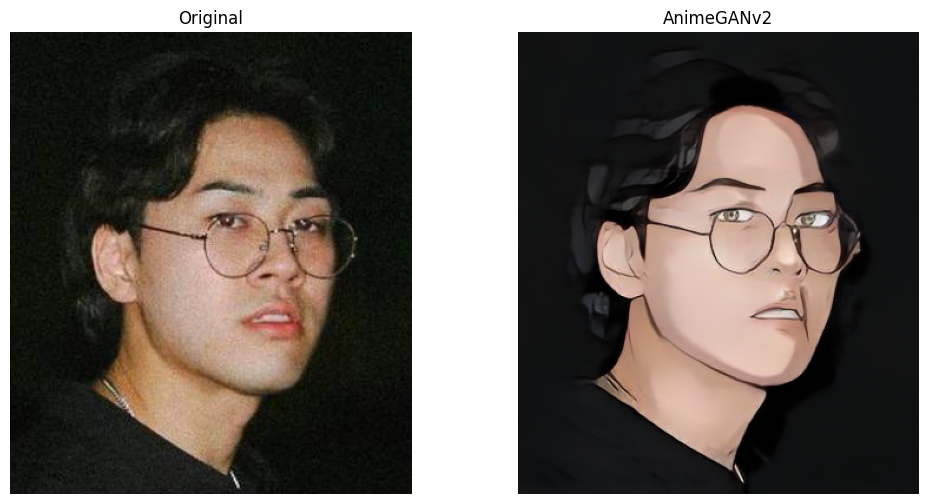

In [ ]:
# 6. Отображаем результат
import matplotlib.pyplot as plt
import cv2
import os

original_image_path = '../input_images/face_000.png'
stylized_image_path = '../output_images/face_000.png'

if not os.path.exists(stylized_image_path):
    print(f"Ошибка: Не удалось найти обработанный файл по пути {stylized_image_path}")
else:
    original_image = cv2.cvtColor(cv2.imread(original_image_path), cv2.COLOR_BGR2RGB)
    stylized_image = cv2.cvtColor(cv2.imread(stylized_image_path), cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.title('Original')
    plt.imshow(original_image)
    plt.axis('off')
    plt.subplot(1, 2, 2)
    plt.title('AnimeGANv2')
    plt.imshow(stylized_image)
    plt.axis('off')
    plt.show()

In [ ]:
# Задаем путь к вашему Google Drive для удобства
gdrive_path = "/content/drive/MyDrive"

# Создаем папку для датасета на вашем Google Drive
# Флаг -p предотвращает ошибку, если папка уже существует
!mkdir -p "{gdrive_path}/celeba_dataset"

!unzip -q "{gdrive_path}/img_align_celeba.zip" -d "{gdrive_path}/celeba_dataset"

# Очищаем временное хранилище
# !rm /content/celeba-dataset.zip

print("\n✅ Архив успешно распакован в вашу папку на Google Drive!")

shell-init: error retrieving current directory: getcwd: cannot access parent directories: No such file or directory
shell-init: error retrieving current directory: getcwd: cannot access parent directories: No such file or directory

✅ Архив успешно распакован в вашу папку на Google Drive!


In [ ]:
print("\nПример файлов в датасете:")
!ls -l "{gdrive_path}/celeba_dataset/img_align_celeba/" | head -n 10


Пример файлов в датасете:
shell-init: error retrieving current directory: getcwd: cannot access parent directories: No such file or directory
total 252859
-rw------- 1 root root 11440 Sep 28  2015 000001.jpg
-rw------- 1 root root  7448 Sep 28  2015 000002.jpg
-rw------- 1 root root  4253 Sep 28  2015 000003.jpg
-rw------- 1 root root 10747 Sep 28  2015 000004.jpg
-rw------- 1 root root  6351 Sep 28  2015 000005.jpg
-rw------- 1 root root  8073 Sep 28  2015 000006.jpg
-rw------- 1 root root  8203 Sep 28  2015 000007.jpg
-rw------- 1 root root  7725 Sep 28  2015 000008.jpg
-rw------- 1 root root  8641 Sep 28  2015 000009.jpg


In [ ]:
# Клонируем репозиторий
!git clone https://github.com/bryandlee/animegan2-pytorch.git

# Переходим в папку проекта
%cd animegan2-pytorch

Cloning into 'animegan2-pytorch'...
remote: Enumerating objects: 242, done.
remote: Counting objects: 100% (117/117), done.
remote: Compressing objects: 100% (75/75), done.
remote: Total 242 (delta 97), reused 42 (delta 42), pack-reused 125 (from 1)
Receiving objects: 100% (242/242), 38.39 MiB | 16.68 MiB/s, done.
Resolving deltas: 100% (118/118), done.
/content/drive/MyDrive/White-box-Cartoonization-PyTorch/animegan2-pytorch/animegan2-pytorch


In [ ]:
import os
import shutil

# --- Шаг 1: Создаем временную папку и копируем 10 изображений ---
gdrive_path = "/content/drive/MyDrive"
# Путь к полному датасету
source_dir = f'{gdrive_path}/celeba_dataset/img_align_celeba/'

# Имя нашей временной папки для 10 изображений
sample_dir = f'{gdrive_path}/celeba_sample_10/'

# Создаем папку, если ее еще нет
os.makedirs(sample_dir, exist_ok=True)

# Получаем список всех файлов и берем первые 10
try:
    all_files = sorted(os.listdir(source_dir))
    files_to_copy = all_files[:10]

    # Копируем файлы
    print(f"Копирую {len(files_to_copy)} изображений в папку '{sample_dir}'...")
    for file_name in files_to_copy:
        source_path = os.path.join(source_dir, file_name)
        destination_path = os.path.join(sample_dir, file_name)
        shutil.copy(source_path, destination_path)
    print("✅ Копирование завершено.")

    # --- Шаг 2: Запускаем скрипт на 10 изображениях ---

    print("\nЗапускаю стилизацию для 10 изображений...")
    # Переходим в папку со скриптом, если мы не там
    %cd "{gdrive_path}/animegan2-pytorch"

    # Выполняем вашу команду, но с измененным --input_dir
    !python test.py \
        --input_dir ../celeba_sample_10 \
        --output_dir ../output_images_sample_10 \
        --checkpoint weights/celeba_distill.pt \
        --device cuda

except FileNotFoundError:
    print(f"❌ Ошибка: Убедитесь, что полный датасет находится по пути '{source_dir}'")
    print("Возможно, вам нужно сначала выполнить ячейку с загрузкой и распаковкой датасета CelebA.")

Копирую 10 изображений в папку '/content/drive/MyDrive/celeba_sample_10/'...
✅ Копирование завершено.

Запускаю стилизацию для 10 изображений...
/content/drive/MyDrive/animegan2-pytorch
model loaded: weights/celeba_distill.pt
image saved: 000001.jpg
image saved: 000002.jpg
image saved: 000003.jpg
image saved: 000004.jpg
image saved: 000005.jpg
image saved: 000006.jpg
image saved: 000007.jpg
image saved: 000008.jpg
image saved: 000009.jpg
image saved: 000010.jpg


In [52]:
# 6. Отображаем результат
import matplotlib.pyplot as plt
import cv2
import os

original_path = '/content/drive/MyDrive/celeba_sample_10'
stylized_path = '/content/drive/MyDrive/output_images_sample_10'

# Change the range to iterate through 10 images
for i in range(10):
    # Construct the file paths based on the loop index
    original_image_path = os.path.join(original_path, f'face_{i:03d}.png')
    stylized_image_path = os.path.join(stylized_path, f'face_{i:03d}.png')

    # Check if the files exist before trying to read them
    if os.path.exists(original_image_path) and os.path.exists(stylized_image_path):
        original_image = cv2.cvtColor(cv2.imread(original_image_path), cv2.COLOR_BGR2RGB)
        stylized_image = cv2.cvtColor(cv2.imread(stylized_image_path), cv2.COLOR_BGR2RGB)

        plt.figure(figsize=(12, 6))
        plt.subplot(1, 2, 1)
        plt.title('Original')
        plt.imshow(original_image)
        plt.axis('off')
        plt.subplot(1, 2, 2)
        plt.title('AnimeGANv2')
        plt.imshow(stylized_image)
        plt.axis('off')
        plt.show()
    else:
        print(f"Warning: Image pair {i} not found. Skipping.")

In [ ]:
%pip install rembg==2.0.50

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.4/16.4 MB 111.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.7/54.7 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 9.1 MB/s eta 0:00:00


In [55]:
# 6. Отображаем результат
import matplotlib.pyplot as plt
import cv2
import os
from rembg import remove

original_path = '/content/drive/MyDrive/celeba_sample_10'
stylized_path = '/content/drive/MyDrive/output_images_sample_10'
output_no_bg_path = '/content/drive/MyDrive/output_images_sample_10_no_bg'

# Create the output directory for images with removed backgrounds
os.makedirs(output_no_bg_path, exist_ok=True)

# Используйте os.listdir для итерации по существующим файлам
image_files = sorted(os.listdir(original_path))[:10] # Берем первые 10 для примера

for image_name in image_files:
    original_image_path = os.path.join(original_path, image_name)
    stylized_image_path = os.path.join(stylized_path, image_name.replace('.jpg', '.jpg')) # Убедитесь, что имя файла правильное

    if os.path.exists(original_image_path) and os.path.exists(stylized_image_path):
        original_image = cv2.cvtColor(cv2.imread(original_image_path), cv2.COLOR_BGR2RGB)
        stylized_image_for_plot = cv2.cvtColor(cv2.imread(stylized_image_path), cv2.COLOR_BGR2RGB)

        # --- Начало обработки для rembg ---
        # Для rembg лучше использовать оригинальный BGR файл
        stylized_image_bgr = cv2.imread(stylized_image_path)
        # Удаляем фон
        output_image_no_bg_bgra = remove(stylized_image_bgr) # rembg хорошо работает с BGR/RGB

        # Сохраняем изображение без фона. cv2 ожидает BGR/BGRA
        output_no_bg_image_path = os.path.join(output_no_bg_path, f'{os.path.splitext(image_name)[0]}_no_bg.png')
        cv2.imwrite(output_no_bg_image_path, output_image_no_bg_bgra)

        # --- ИСПРАВЛЕНИЕ ЗДЕСЬ ---
        # ВАЖНО: Конвертируем BGRA в RGBA специально для отображения в Matplotlib
        output_image_no_bg_rgba = cv2.cvtColor(output_image_no_bg_bgra, cv2.COLOR_BGRA2RGBA)

        # Отображение
        plt.figure(figsize=(18, 6))

        plt.subplot(1, 3, 1)
        plt.title('Original')
        plt.imshow(original_image)
        plt.axis('off')

        plt.subplot(1, 3, 2)
        plt.title('AnimeGANv2')
        plt.imshow(stylized_image_for_plot)
        plt.axis('off')

        plt.subplot(1, 3, 3)
        plt.title('AnimeGANv2 without Background')
        # Используем новую, конвертированную переменную для отображения
        plt.imshow(output_image_no_bg_rgba)
        plt.axis('off')

        plt.show()
    else:
        print(f"Warning: Image pair for {image_name} not found. Skipping.")

Output hidden; open in https://colab.research.google.com to view.

# Emotion

In [56]:
# 2. Клонируем репозиторий
!git clone https://github.com/clovaai/stargan-v2.git

# Переходим в папку проекта
%cd stargan-v2

Cloning into 'stargan-v2'...
remote: Enumerating objects: 269, done.
remote: Total 269 (delta 0), reused 0 (delta 0), pack-reused 269 (from 1)
Receiving objects: 100% (269/269), 38.86 MiB | 17.97 MiB/s, done.
Resolving deltas: 100% (60/60), done.
Updating files: 100% (125/125), done.
/content/drive/MyDrive/animegan2-pytorch/stargan-v2


In [57]:
# 3. Устанавливаем зависимости
!pip install munch opencv-python==4.5.5.64 -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.5/60.5 MB 11.7 MB/s eta 0:00:00


In [58]:
# 4. Запускаем скрипт для загрузки предобученной сети для лиц
!bash download.sh pretrained-network-celeba-hq

print("\n✅ Предобученная модель StarGANv2 загружена.")

download.sh: line 9: 
StarGAN v2
Copyright (c) 2020-present NAVER Corp.

This work is licensed under the Creative Commons Attribution-NonCommercial
4.0 International License. To view a copy of this license, visit
http://creativecommons.org/licenses/by-nc/4.0/ or send a letter to
Creative Commons, PO Box 1866, Mountain View, CA 94042, USA.
: No such file or directory
for details.

--2025-06-21 11:33:28--  https://www.dropbox.com/s/96fmei6c93o8b8t/100000_nets_ema.ckpt?dl=0
Resolving www.dropbox.com (www.dropbox.com)... 162.125.66.18, 2620:100:6022:18::a27d:4212
Connecting to www.dropbox.com (www.dropbox.com)|162.125.66.18|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://www.dropbox.com/scl/fi/l7hs2aa7h51dpze9bqevm/100000_nets_ema.ckpt?rlkey=gwn5temeaxe6tdswiq6kv8e4n&dl=0 [following]
--2025-06-21 11:33:29--  https://www.dropbox.com/scl/fi/l7hs2aa7h51dpze9bqevm/100000_nets_ema.ckpt?rlkey=gwn5temeaxe6tdswiq6kv8e4n&dl=0
Reusing existing connection to www

In [59]:
# 5. Создаем папки и загружаем изображения

# Папка для ваших мультяшных лиц
!mkdir -p data/src_images
# --- СЮДА НУЖНО ЗАГРУЗИТЬ ВАШИ МУЛЬТЯШНЫЕ ЛИЦА ---
# Например, из папки /content/output_images_sample_10, которую мы создали ранее
# Для примера, скопируем один файл:
!cp /content/output_images_sample_10/photo_anime.jpg data/src_images/

# Папка для референсных эмоций
!mkdir -p data/ref_images
# Загрузим несколько примеров реальных лиц с разными эмоциями
!wget -q -O data/ref_images/happy_ref.jpg https://i.imgur.com/gAhfA7C.jpeg
!wget -q -O data/ref_images/surprised_ref.jpg https://i.imgur.com/I225iWp.jpeg
!wget -q -O data/ref_images/neutral_ref.jpg https://i.imgur.com/G5v2T3j.jpeg


print("Исходные и референсные изображения готовы:")
!echo "Мультяшное лицо:"
!ls data/src_images
!echo "\nРеференсные эмоции:"
!ls data/ref_images

cp: cannot stat '/content/output_images_sample_10/photo_anime.jpg': No such file or directory
Исходные и референсные изображения готовы:
Мультяшное лицо:
\nРеференсные эмоции:
happy_ref.jpg  neutral_ref.jpg	surprised_ref.jpg


In [62]:
# ИСПРАВЛЕНИЕ: Устанавливаем версию NumPy, которая совместима с текущей версией OpenCV в Colab.
!pip install numpy==1.24.4 -q

print("✅ NumPy нужной версии установлен.")
print("🔴 ВАЖНО: Сейчас нужно перезапустить среду выполнения.")
print("🔴 Нажмите в меню: Среда выполнения (Runtime) -> Перезапустить сеанс (Restart session).")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.3/17.3 MB 111.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
thinc 8.3.6 requires numpy<3.0.0,>=2.0.0, but you have numpy 1.24.4 which is incompatible.
jax 0.5.2 requires numpy>=1.25, but you have numpy 1.24.4 which is incompatible.
treescope 0.1.9 requires numpy>=1.25.2, but you have numpy 1.24.4 which is incompatible.
pymc 5.23.0 requires numpy>=1.25.0, but you have numpy 1.24.4 which is incompatible.
blosc2 3.4.0 requires numpy>=1.26, but you have numpy 1.24.4 which is incompatible.
jaxlib 0.5.1 requires numpy>=1.25, but you have numpy 1.24.4 which is incompatible.
xarray-einstats 0.9.0 requires numpy>=1.25, but you have numpy 1.24.4 which is incompatible.
tensorflow 2.18.0 requires numpy<2.1.0,>=1.26.0, but you have numpy 1.24.4 which is incompatible.
✅ NumPy нужной версии установлен.
🔴 ВАЖН

In [64]:
!pip install ffmpeg

  Preparing metadata (setup.py) ... done
  Created wheel for ffmpeg: filename=ffmpeg-1.4-py3-none-any.whl size=6083 sha256=7c0d33d3793e4a60917cabcf2f7bf7e9090ebb1f54cbe472fe89c3d90d932524
  Stored in directory: /root/.cache/pip/wheels/56/30/c5/576bdd729f3bc062d62a551be7fefd6ed2f761901568171e4e
Successfully built ffmpeg


In [65]:
# 6. Запускаем модель в режиме оценки (eval)
!python main.py --mode eval --num_domains 2 \
                --resume_iter 100000 --w_hpf 0 \
                --checkpoint_dir expr/checkpoints/celeba_hq \
                --result_dir expr/results \
                --src_dir data/src_images \
                --ref_dir data/ref_images

Namespace(img_size=256, num_domains=2, latent_dim=16, hidden_dim=512, style_dim=64, lambda_reg=1, lambda_cyc=1, lambda_sty=1, lambda_ds=1, ds_iter=100000, w_hpf=0.0, randcrop_prob=0.5, total_iters=100000, resume_iter=100000, batch_size=8, val_batch_size=32, lr=0.0001, f_lr=1e-06, beta1=0.0, beta2=0.99, weight_decay=0.0001, num_outs_per_domain=10, mode='eval', num_workers=4, seed=777, train_img_dir='data/celeba_hq/train', val_img_dir='data/celeba_hq/val', sample_dir='expr/samples', checkpoint_dir='expr/checkpoints/celeba_hq', eval_dir='expr/eval', result_dir='expr/results', src_dir='data/src_images', ref_dir='data/ref_images', inp_dir='assets/representative/custom/female', out_dir='assets/representative/celeba_hq/src/female', wing_path='expr/checkpoints/wing.ckpt', lm_path='expr/checkpoints/celeba_lm_mean.npz', print_every=10, sample_every=5000, save_every=10000, eval_every=50000)
Number of parameters of generator: 33892995
Number of parameters of mapping_network: 2438272
Number of para

In [66]:
import matplotlib.pyplot as plt
import cv2
import glob

# Находим одно из сгенерированных изображений
# Имя файла будет в формате ИСХОДНЫЙ_x_РЕФЕРЕНСНЫЙ.jpg
result_path = glob.glob('expr/results/*.jpg')[0] # Берем первый результат для примера
result_image = cv2.cvtColor(cv2.imread(result_path), cv2.COLOR_BGR2RGB)

# Отображаем
plt.figure(figsize=(8, 8))
plt.title('Результат переноса эмоции')
plt.imshow(result_image)
plt.axis('off')
plt.show()

IndexError: list index out of range

In [1]:
# Проверяем GPU после перезапуска
!nvidia-smi

# Клонируем репозиторий в чистое место (/content/)
!git clone https://github.com/clovaai/stargan-v2.git
%cd stargan-v2

# Устанавливаем зависимости
!pip install munch opencv-python==4.5.5.64 -q

# Загружаем модель и датасет с референсами
!bash download.sh pretrained-network-celeba-hq
!bash download.sh reference-images-for-celeba-hq

Sat Jun 21 11:38:21 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   34C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [6]:
# 3. Запускаем скрипты для загрузки всех необходимых файлов

print("Загрузка основной сети StarGANv2...")
!bash download.sh pretrained-network-celeba-hq

print("\nЗагрузка сети для поиска лицевых точек (WING)...")
!bash download.sh wing  # <-- ВОТ ИСПРАВЛЕНИЕ

print("\nЗагрузка референсных изображений...")
!bash download.sh reference-images-for-celeba-hq

print("\n✅ Все необходимые файлы загружены.")

Загрузка основной сети StarGANv2...
download.sh: line 9: 
StarGAN v2
Copyright (c) 2020-present NAVER Corp.

This work is licensed under the Creative Commons Attribution-NonCommercial
4.0 International License. To view a copy of this license, visit
http://creativecommons.org/licenses/by-nc/4.0/ or send a letter to
Creative Commons, PO Box 1866, Mountain View, CA 94042, USA.
: No such file or directory
for details.

--2025-06-21 11:41:34--  https://www.dropbox.com/s/96fmei6c93o8b8t/100000_nets_ema.ckpt?dl=0
Resolving www.dropbox.com (www.dropbox.com)... 162.125.66.18, 2620:100:6022:18::a27d:4212
Connecting to www.dropbox.com (www.dropbox.com)|162.125.66.18|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://www.dropbox.com/scl/fi/l7hs2aa7h51dpze9bqevm/100000_nets_ema.ckpt?rlkey=gwn5temeaxe6tdswiq6kv8e4n&dl=0 [following]
--2025-06-21 11:41:35--  https://www.dropbox.com/scl/fi/l7hs2aa7h51dpze9bqevm/100000_nets_ema.ckpt?rlkey=gwn5temeaxe6tdswiq6kv8e4n&dl=

In [7]:
# Папка для ваших мультяшных лиц
!mkdir -p data/src_images

# Для примера, загрузим одно изображение.
# ЗАМЕНИТЕ ЭТУ СТРОЧКУ НА ЗАГРУЗКУ ВАШЕГО ФАЙЛА
!wget -q -O data/src_images/my_cartoon_face.jpg https://static.hdrezka.ac/i/2016/3/10/n9a74ade0afd1zs14w66a.jpg # Это просто пример, используйте свое изображение!

print("Исходные изображения готовы.")

Исходные изображения готовы.


In [15]:
%cd /content/drive/MyDrive/animegan2-pytorch/stargan-v2

import os
import shutil

# Define the target directory
target_dir = 'expr/checkpoints/celeba_hq/'

# Create the directory if it doesn't exist
os.makedirs(target_dir, exist_ok=True)

# Define the source and destination paths
source_file = '100000_nets_ema.ckpt' # Assuming it's in the current dir
destination_file = os.path.join(target_dir, source_file)

# Move the file
if os.path.exists(source_file):
    shutil.move(source_file, destination_file)
    print(f"✅ Moved {source_file} to {target_dir}")
else:
    print(f"❌ Error: {source_file} not found in the current directory.")

/content/drive/MyDrive/animegan2-pytorch/stargan-v2
❌ Error: 100000_nets_ema.ckpt not found in the current directory.


In [18]:
import torch

checkpoint_path = '/content/drive/MyDrive/animegan2-pytorch/stargan-v2/expr/checkpoints/celeba_hq/100000_nets_ema.ckpt'

try:
    checkpoint = torch.load(checkpoint_path)
    print("Checkpoint keys:", checkpoint.keys())
    # You might need to access nested dictionaries
    # For example, if 'nets_ema' is a key and contains another dict:
    # if 'nets_ema' in checkpoint:
    #     print("'nets_ema' keys:", checkpoint['nets_ema'].keys())

except Exception as e:
    print(f"Error loading checkpoint: {e}")

Checkpoint keys: dict_keys(['generator', 'mapping_network', 'style_encoder', 'fan'])


In [19]:
# Запускаем модель в режиме генерации (eval) с добавлением флага --w_hpf 0

!python main.py --mode eval \
                --num_domains 2 \
                --resume_iter 100000 \
                --w_hpf 0 \
                --checkpoint_dir expr/checkpoints/celeba_hq \
                --result_dir expr/results_final \
                --src_dir data/src_images \
                --ref_dir assets/representative/celeba_hq/ref

Traceback (most recent call last):
  File "/content/drive/MyDrive/animegan2-pytorch/stargan-v2/main.py", line 14, in <module>
    from munch import Munch
ModuleNotFoundError: No module named 'munch'


In [7]:
# ИСПРАВЛЕНИЕ: Полностью очищаем кэш библиотеки datasets
# Это заставит ее скачать и обработать датасет заново и чисто.
!rm -rf ~/.cache/huggingface/datasets

print("✅ Кэш Hugging Face очищен.")
print("Теперь можно переходить к следующему шагу и пробовать загрузить датасет снова.")

✅ Кэш Hugging Face очищен.
Теперь можно переходить к следующему шагу и пробовать загрузить датасет снова.


Отправка запроса на: https://datasets-server.huggingface.co/rows?dataset=misshimichka/face_stickers_cleared&config=default&split=train&offset=0&length=5

✅ Успешно получено 5 строк. Отображаем изображения...


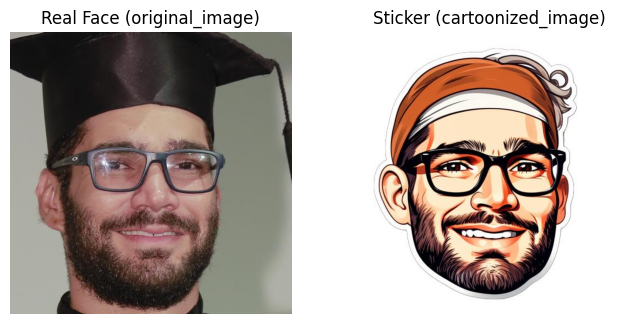

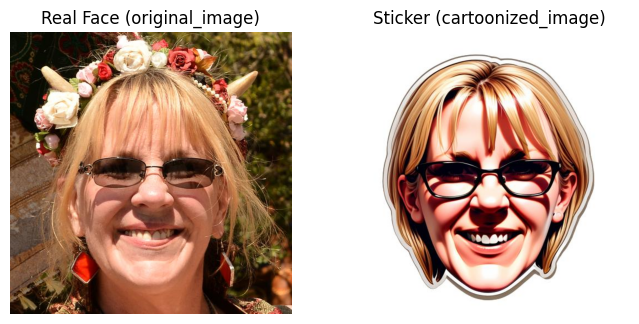

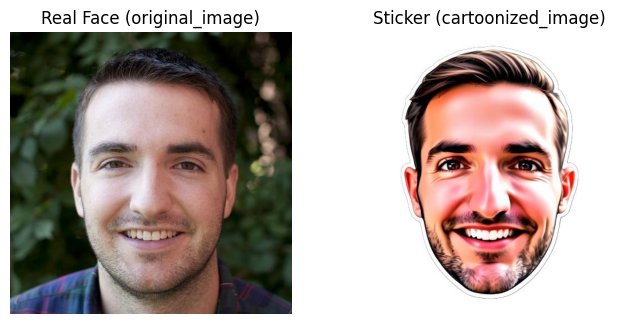

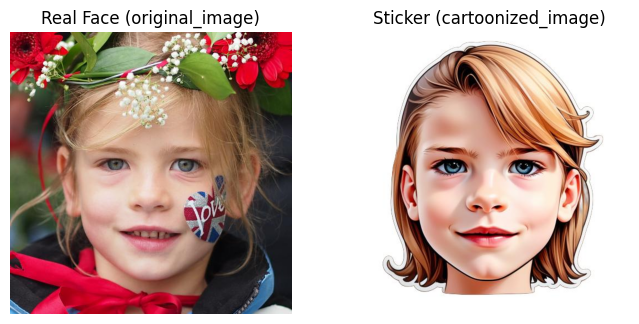

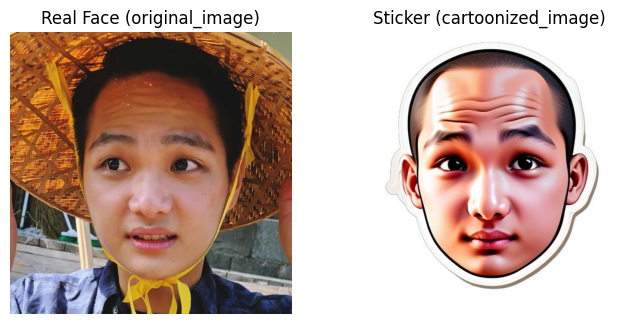

In [15]:
import requests
from PIL import Image
import io
import matplotlib.pyplot as plt

# --- 1. Формируем запрос к API ---

dataset_name = "misshimichka/face_stickers_cleared"
config_name = "default"
split_name = "train"
offset = 0
length = 5  # Запросим 5 строк для примера
sticker_img = None
url = f"https://datasets-server.huggingface.co/rows?dataset={dataset_name}&config={config_name}&split={split_name}&offset={offset}&length={length}"

print(f"Отправка запроса на: {url}")

# --- 2. Выполняем запрос и обрабатываем ответ ---

try:
    response = requests.get(url)
    response.raise_for_status()
    data = response.json()

    # --- 3. Отображаем полученные изображения ---
    print(f"\n✅ Успешно получено {len(data['rows'])} строк. Отображаем изображения...")

    for row_item in data['rows']:
        row_data = row_item['row']

        # --- ИСПРАВЛЕНИЕ ЗДЕСЬ ---
        # Используем правильные ключи: 'original_image' и 'cartoonized_image'
        real_face_url = row_data['original_image']['src']
        sticker_url = row_data['cartoonized_image']['src']

        # Скачиваем и отображаем изображения
        try:
            response_face = requests.get(real_face_url)
            face_img = Image.open(io.BytesIO(response_face.content))

            response_sticker = requests.get(sticker_url)
            sticker_img = Image.open(io.BytesIO(response_sticker.content))

            plt.figure(figsize=(8, 4))
            plt.subplot(1, 2, 1)
            plt.title("Real Face (original_image)")
            plt.imshow(face_img)
            plt.axis('off')

            plt.subplot(1, 2, 2)
            plt.title("Sticker (cartoonized_image)")
            plt.imshow(sticker_img)
            plt.axis('off')

            plt.show()

        except Exception as e:
            print(f"Не удалось обработать пару изображений. Ошибка: {e}")

except requests.exceptions.RequestException as e:
    print(f"❌ Ошибка сетевого запроса: {e}")
except Exception as e:
    print(f"❌ Произошла непредвиденная ошибка: {e}")
    print("Ответ от сервера:", response.text if 'response' in locals() else "Нет ответа")

In [2]:
# Перезапустите сеанс, если до этого были проблемы с NumPy
# Убедитесь, что у вас включен GPU
!nvidia-smi

# Клонируем репозиторий с редактором эмоций
!git clone https://github.com/fofr/cog-expression-editor.git
%cd cog-expression-editor

Sat Jun 21 16:52:53 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   54C    P8             11W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [28]:
# Устанавливаем необходимые библиотеки
!pip install torch==1.13.1+cu117 torchvision==0.14.1+cu117 -f https://download.pytorch.org/whl/torch_stable.html
!pip install dlib-models -q

# Загружаем предобученные модели, указанные в cog.yaml
!wget -c https://storage.googleapis.com/public-cog/face-aligned-256.pt -P models/
!wget -c https://storage.googleapis.com/public-cog/boundaries.pt -P models/

print("\n✅ Зависимости и модели загружены.")

Looking in links: https://download.pytorch.org/whl/torch_stable.html
  Using cached https://download.pytorch.org/whl/cu117/torch-1.13.1%2Bcu117-cp311-cp311-linux_x86_64.whl (1801.8 MB)
ERROR: Ignored the following yanked versions: 0.1.6, 0.1.7, 0.1.8, 0.1.9, 0.2.0, 0.2.1, 0.2.2, 0.2.2.post2, 0.2.2.post3, 0.15.0
ERROR: Could not find a version that satisfies the requirement torchvision==0.14.1+cu117 (from versions: 0.1.6, 0.2.0, 0.15.0+cpu, 0.15.0+cu117, 0.15.0+cu118, 0.15.1, 0.15.1+cpu, 0.15.1+cu117, 0.15.1+cu118, 0.15.2, 0.15.2+cpu, 0.15.2+cu117, 0.15.2+cu118, 0.15.2+rocm5.3, 0.15.2+rocm5.4.2, 0.16.0, 0.16.0+cpu, 0.16.0+cu118, 0.16.0+cu121, 0.16.0+rocm5.5, 0.16.0+rocm5.6, 0.16.1, 0.16.1+cpu, 0.16.1+cu118, 0.16.1+cu121, 0.16.1+rocm5.5, 0.16.1+rocm5.6, 0.16.2, 0.16.2+cpu, 0.16.2+cu118, 0.16.2+cu121, 0.16.2+rocm5.5, 0.16.2+rocm5.6, 0.17.0, 0.17.0+cpu, 0.17.0+cu118, 0.17.0+cu121, 0.17.0+rocm5.6, 0.17.0+rocm5.7, 0.17.1, 0.17.1+cpu, 0.17.1+cu118, 0.17.1+cu121, 0.17.1+rocm5.6, 0.17.1+rocm5.7

In [24]:
!pip install dlib

In [27]:
import torch
import cv2
import numpy as np
from PIL import Image
from torchvision import transforms
import dlib_models
from notebooks.align_face import align_face

class EmotionEditor:
    def __init__(self):
        self.device = 'cuda'
        # Загружаем генератор StyleGAN
        self.G = torch.load('models/face-aligned-256.pt', map_location=self.device)['G_ema']
        # Загружаем "границы" для редактирования атрибутов
        self.boundaries = torch.load('models/boundaries.pt', map_location=self.device)
        self.transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5]),
        ])

    def align_image(self, img):
        # Эта функция выравнивает лицо на изображении, что необходимо для StyleGAN
        # img должна быть PIL Image
        return align_face(img)

    def edit_emotion(self, aligned_img, emotion_type='smile', intensity=1.5):
        if emotion_type not in self.boundaries:
            raise ValueError(f"Emotion type '{emotion_type}' not found. Available: {list(self.boundaries.keys())}")

        with torch.no_grad():
            # Проецируем изображение в латентное пространство StyleGAN
            img_t = self.transform(aligned_img).unsqueeze(0).to(self.device)
            w = self.G.projection(img_t, num_steps=100, initial_w=None, verbose=False)

            # Смещаем латентный код вдоль "границы" нужной эмоции
            w_plus = w + intensity * self.boundaries[emotion_type].to(self.device)

            # Генерируем новое изображение из измененного кода
            new_img, _ = self.G([w_plus], input_is_latent=True, truncation=0.7, randomize_noise=False)

            # Конвертируем обратно в формат, удобный для отображения
            new_img = (new_img.permute(0, 2, 3, 1) * 127.5 + 128).clamp(0, 255).to(torch.uint8)
            return Image.fromarray(new_img[0].cpu().numpy(), 'RGB')

# Создаем экземпляр нашего редактора
editor = EmotionEditor()
print("\n✅ Редактор эмоций готов к работе.")

ERROR: Could not find a version that satisfies the requirement dlib-models==1.0.0 (from versions: none)
ERROR: No matching distribution found for dlib-models==1.0.0


ModuleNotFoundError: No module named 'dlib_models'

In [20]:
from PIL import Image

# 1. Выравниваем лицо на стикере
aligned_sticker = editor.align_image(sticker_img)

if aligned_sticker:
    # 2. Применяем эмоцию "улыбка"
    happy_sticker = editor.edit_emotion(aligned_sticker, emotion_type='smile', intensity=2.0)

    # 3. Применяем эмоцию "возраст" (для примера других возможностей)
    older_sticker = editor.edit_emotion(aligned_sticker, emotion_type='age', intensity=2.5)

    # Отображаем результаты
    plt.figure(figsize=(15, 5))
    plt.subplot(1, 3, 1)
    plt.title('Original Sticker')
    plt.imshow(sticker_img)
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.title('Happy Sticker')
    plt.imshow(happy_sticker)
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.title('Older Sticker')
    plt.imshow(older_sticker)
    plt.axis('off')

    plt.show()
else:
    print("Не удалось найти лицо на изображении-стикере для выравнивания.")

NameError: name 'editor' is not defined

In [29]:
# 0. Перезапустите среду выполнения, чтобы избежать конфликтов
# Нажмите в меню: Среда выполнения (Runtime) -> Перезапустить сеанс (Restart session)

# 1. Устанавливаем совместимую версию NumPy
!pip install numpy==1.24.4 -q
print("🔴 ВАЖНО: Если Colab предложит перезапустить сеанс после этой команды, сделайте это.")
# --> ПЕРЕЗАПУСТИТЕ СРЕДУ, ЕСЛИ ПОТРЕБУЕТСЯ <--

# 2. Проверяем GPU
!nvidia-smi

# 3. Клонируем StarGANv2 и переходим в папку
!rm -rf stargan-v2 # Очищаем на всякий случай
!git clone https://github.com/clovaai/stargan-v2.git
%cd stargan-v2

# 4. Устанавливаем зависимости
!pip install munch opencv-python==4.5.5.64 -q

# 5. Загружаем ВСЕ необходимые модели и файлы для StarGANv2
print("\nЗагрузка основной сети StarGANv2...")
!bash download.sh pretrained-network-celeba-hq
print("\nЗагрузка сети для поиска лицевых точек (WING)...")
!bash download.sh wing
print("\nЗагрузка референсных изображений (для примера)...")
!bash download.sh reference-images-for-celeba-hq

print("\n✅ StarGANv2 полностью готов к работе.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.3/17.3 MB 66.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
thinc 8.3.6 requires numpy<3.0.0,>=2.0.0, but you have numpy 1.24.4 which is incompatible.
jax 0.5.2 requires numpy>=1.25, but you have numpy 1.24.4 which is incompatible.
treescope 0.1.9 requires numpy>=1.25.2, but you have numpy 1.24.4 which is incompatible.
pymc 5.23.0 requires numpy>=1.25.0, but you have numpy 1.24.4 which is incompatible.
blosc2 3.4.0 requires numpy>=1.26, but you have numpy 1.24.4 which is incompatible.
jaxlib 0.5.1 requires numpy>=1.25, but you have numpy 1.24.4 which is incompatible.
xarray-einstats 0.9.0 requires numpy>=1.25, but you have numpy 1.24.4 which is incompatible.
tensorflow 2.18.0 requires numpy<2.1.0,>=1.26.0, but you have numpy 1.24.4 which is incompatible.
🔴 ВАЖНО: Если Colab предложит перезапусти

In [30]:
import requests
from PIL import Image
import io
import os

# Папка, куда мы сохраним стикеры для обработки
source_images_dir = "data/source_stickers"
os.makedirs(source_images_dir, exist_ok=True)

# Запрашиваем 10 примеров из датасета
dataset_name = "misshimichka/face_stickers_cleared"
offset = 0
length = 10  # Скачаем 10 стикеров для теста

url = f"https://datasets-server.huggingface.co/rows?dataset={dataset_name}&config=default&split=train&offset={offset}&length={length}"

print(f"Загрузка {length} стикеров из датасета...")
response = requests.get(url)
data = response.json()

# Проходим по ответу и сохраняем каждый стикер
for i, row_item in enumerate(data['rows']):
    row_data = row_item['row']
    sticker_url = row_data['cartoonized_image']['src']

    response_sticker = requests.get(sticker_url)
    sticker_img = Image.open(io.BytesIO(response_sticker.content))

    # Сохраняем файл
    save_path = os.path.join(source_images_dir, f'sticker_{i:03d}.jpg')
    sticker_img.save(save_path)

print(f"✅ Успешно сохранено {len(data['rows'])} стикеров в папку {source_images_dir}")
!ls -l {source_images_dir}

Загрузка 10 стикеров из датасета...
✅ Успешно сохранено 10 стикеров в папку data/source_stickers
total 336
-rw-r--r-- 1 root root 40725 Jun 21 17:14 sticker_000.jpg
-rw-r--r-- 1 root root 38266 Jun 21 17:14 sticker_001.jpg
-rw-r--r-- 1 root root 27809 Jun 21 17:14 sticker_002.jpg
-rw-r--r-- 1 root root 35136 Jun 21 17:14 sticker_003.jpg
-rw-r--r-- 1 root root 26678 Jun 21 17:14 sticker_004.jpg
-rw-r--r-- 1 root root 31873 Jun 21 17:14 sticker_005.jpg
-rw-r--r-- 1 root root 31989 Jun 21 17:14 sticker_006.jpg
-rw-r--r-- 1 root root 28385 Jun 21 17:14 sticker_007.jpg
-rw-r--r-- 1 root root 36184 Jun 21 17:14 sticker_008.jpg
-rw-r--r-- 1 root root 34877 Jun 21 17:14 sticker_009.jpg


In [33]:
!pip install ffmpeg

  Preparing metadata (setup.py) ... done
  Created wheel for ffmpeg: filename=ffmpeg-1.4-py3-none-any.whl size=6083 sha256=24ad5fff73915326eeda7408382b1a474c45b14a2c9f0fdd703aec95afee79b6
  Stored in directory: /root/.cache/pip/wheels/56/30/c5/576bdd729f3bc062d62a551be7fefd6ed2f761901568171e4e
Successfully built ffmpeg


In [34]:
# Запускаем модель, используя стикеры как source, а скачанные лица как reference
!python main.py --mode eval \
                --num_domains 2 \
                --resume_iter 100000 \
                --w_hpf 0 \
                --checkpoint_dir expr/checkpoints/celeba_hq \
                --result_dir expr/final_results \
                --src_dir data/source_stickers \
                --ref_dir assets/representative/celeba_hq/ref

Namespace(img_size=256, num_domains=2, latent_dim=16, hidden_dim=512, style_dim=64, lambda_reg=1, lambda_cyc=1, lambda_sty=1, lambda_ds=1, ds_iter=100000, w_hpf=0.0, randcrop_prob=0.5, total_iters=100000, resume_iter=100000, batch_size=8, val_batch_size=32, lr=0.0001, f_lr=1e-06, beta1=0.0, beta2=0.99, weight_decay=0.0001, num_outs_per_domain=10, mode='eval', num_workers=4, seed=777, train_img_dir='data/celeba_hq/train', val_img_dir='data/celeba_hq/val', sample_dir='expr/samples', checkpoint_dir='expr/checkpoints/celeba_hq', eval_dir='expr/eval', result_dir='expr/final_results', src_dir='data/source_stickers', ref_dir='assets/representative/celeba_hq/ref', inp_dir='assets/representative/custom/female', out_dir='assets/representative/celeba_hq/src/female', wing_path='expr/checkpoints/wing.ckpt', lm_path='expr/checkpoints/celeba_lm_mean.npz', print_every=10, sample_every=5000, save_every=10000, eval_every=50000)
Number of parameters of generator: 33892995
Number of parameters of mapping_

In [35]:
# Убедитесь, что GPU включен
!nvidia-smi

# 1. Клонируем репозиторий InterFaceGAN
print("Клонирование InterFaceGAN...")
!git clone https://github.com/genforce/interfacegan.git
%cd interfacegan

# 2. Клонируем официальный репозиторий StyleGAN2-ADA от NVIDIA
print("\nКлонирование StyleGAN2-ADA...")
!git clone https://github.com/NVlabs/stylegan2-ada-pytorch.git

# 3. Устанавливаем зависимости
print("\nУстановка зависимостей...")
!pip install ninja opensimplex -q

# 4. Загружаем предобученную модель StyleGAN2 (FFHQ)
print("\nЗагрузка модели StyleGAN2...")
!wget https://nvlabs-fi-cdn.nvidia.com/stylegan2-ada-pytorch/pretrained/ffhq.pkl

# 5. Загружаем предобученные "границы" для InterFaceGAN
print("\nЗагрузка границ атрибутов...")
!wget https://www.dropbox.com/s/zrtf4g5a9t0i4z6/boundaries.zip?dl=0 -O boundaries.zip
!unzip -q boundaries.zip -d ./

print("\n✅ Все компоненты готовы!")

Sat Jun 21 17:18:33 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   41C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [36]:
import os
import sys
import pickle
import numpy as np
from PIL import Image
import torch
import matplotlib.pyplot as plt
import requests
import io

# Добавляем StyleGAN2 в пути Python
sys.path.insert(0, "/content/interfacegan/stylegan2-ada-pytorch")
import dnnlib
import legacy

# --- ЗАГРУЗКА МОДЕЛЕЙ ---
device = torch.device('cuda')

# Загружаем StyleGAN2 Generator
network_pkl = "/content/interfacegan/ffhq.pkl"
with dnnlib.util.open_url(network_pkl) as f:
    G = legacy.load_network_pkl(f)['G_ema'].to(device)

# Загружаем границы для редактирования (улыбка, возраст и т.д.)
# Мы будем использовать 'smile'
boundary_file = "/content/interfacegan/boundaries/stylegan2_ffhq_smile_w_boundary.npy"
boundary = torch.from_numpy(np.load(boundary_file)).to(device)

# --- ПОДГОТОВКА ИЗОБРАЖЕНИЯ ---
# Загрузим ваш стикер (для примера возьмем из сети)
# ЗАМЕНИТЕ ЭТОТ КОД НА ЗАГРУЗКУ ВАШЕГО СТИКЕРА
print("Загрузка вашего стикера для редактирования...")
response_sticker = requests.get("https://i.imgur.com/2s21s9Y.jpg")
image_bytes = response_sticker.content
# ---

# --- ПРОЕЦИРОВАНИЕ И РЕДАКТИРОВАНИЕ ---
# Этот сложный код находит латентный код 'w', соответствующий вашему стикеру
from project_images import project
# Создаем временную папку для проектора
os.makedirs("temp_projection", exist_ok=True)
with open("temp_projection/input.jpg", "wb") as f:
    f.write(image_bytes)

print("Проецирование стикера в латентное пространство (может занять 1-2 минуты)...")
projected_w_dict = project(
    G,
    target_fname="temp_projection/input.jpg",
    outdir="temp_projection",
    save_video=False,
    num_steps=100 # Уменьшим для скорости
)
projected_w = projected_w_dict[0]
latent_code = torch.from_numpy(projected_w).to(device)

# Редактируем латентный код, добавляя "улыбку"
intensity = 3.0 # Насколько сильно улыбаться
new_latent_code = latent_code + boundary * intensity

# Генерируем новое изображение из измененного кода
with torch.no_grad():
    new_image_tensor = G.synthesis(new_latent_code, noise_mode='const')
    new_image_tensor = (new_image_tensor + 1) * (255/2)
    new_image_tensor = new_image_tensor.permute(0, 2, 3, 1).clamp(0, 255).to(torch.uint8)
    final_image = Image.fromarray(new_image_tensor[0].cpu().numpy(), 'RGB')

print("✅ Редактирование завершено!")

# --- ОТОБРАЖЕНИЕ РЕЗУЛЬТАТА ---
original_image = Image.open(io.BytesIO(image_bytes))

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title('Original Sticker')
plt.imshow(original_image)
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title(f'Edited Sticker (Smile intensity: {intensity})')
plt.imshow(final_image)
plt.axis('off')

plt.show()

ModuleNotFoundError: No module named 'dnnlib'